# Customer Intelligence System — Country Segmentation

End-to-end pipeline: unsupervised segmentation (KMeans, DBSCAN) generates development-tier
labels for 167 countries, then supervised classifiers (Logistic Regression, Random Forest,
XGBoost) are trained on those labels so any new country can be scored instantly, without
re-running clustering. See `README.md` for the project structure and `src/predict.py` for
the standalone scoring script.

In [1]:
import sys, os
sys.path.append(os.path.abspath("src"))

import numpy as np
import pandas as pd
from IPython.display import Image

import config
import data_prep
import pipeline
import classification

df = pd.read_csv(config.DATA_PATH)
df.columns = [c.strip().lower() for c in df.columns]
df = df.drop_duplicates()
print("Shape:", df.shape)
df.head()

Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 1. Exploratory Data Analysis

Every feature has IQR outliers — expected for country-level data (a handful of very poor
or very rich countries pull the tails). We keep every row: these "outliers" are exactly
the extreme cases a Needs-Aid/Developed segmentation exists to separate. Dropping them
would remove the signal, not noise.

In [2]:
eda = pipeline.run_eda(df)
print("EDA figures written to:", config.FIGURES_DIR)

EDA figures written to: /home/claude/cis/reports/figures


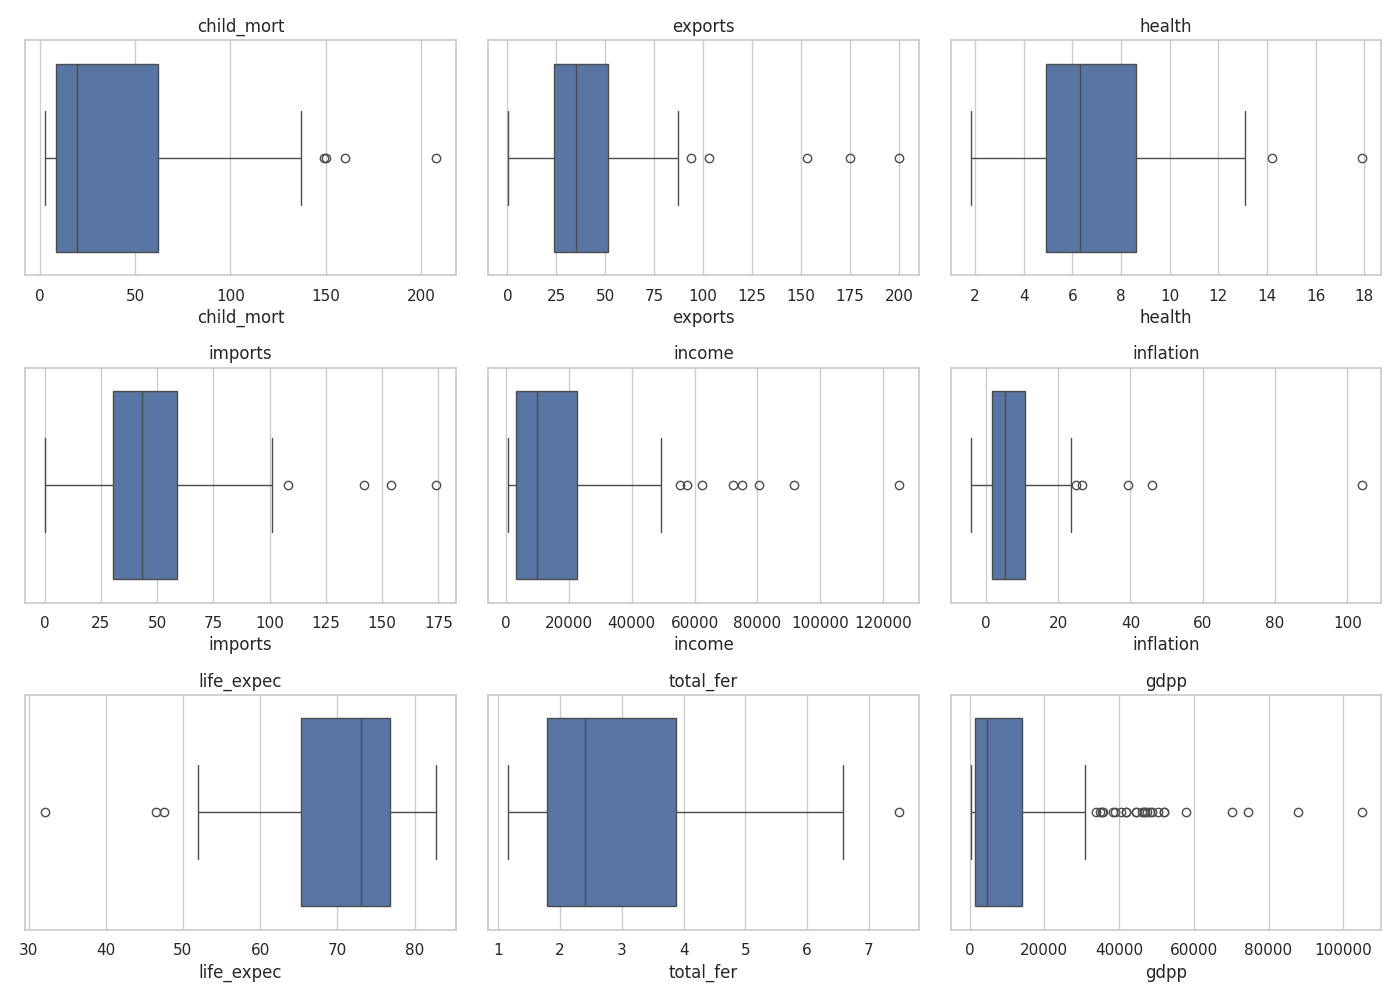

In [3]:
display(Image(filename=str(config.FIGURES_DIR / "01_boxplots.png")))

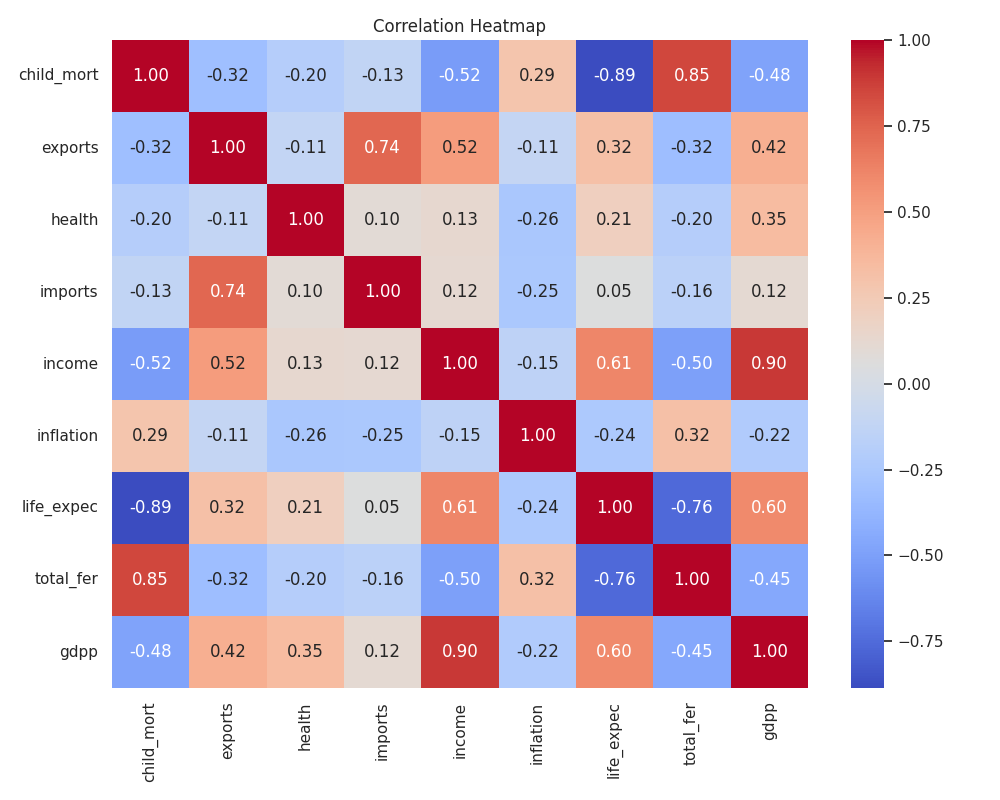

In [4]:
display(Image(filename=str(config.FIGURES_DIR / "02_correlation_heatmap.png")))

`income` and `gdpp` are strongly correlated (both measure economic output per person),
as are `imports`/`exports`. `child_mort` and `life_expec` are strongly *negatively*
correlated, as expected. None of this is surprising, but it's worth confirming before
clustering on all 9 features — highly correlated features implicitly get double weight
in a Euclidean-distance method like KMeans.

In [5]:
skew = data_prep.check_skew(df)
print(skew.to_string(index=False))

 5.154049
 2.445824
 2.231480
 2.218051
 1.905276
 1.450774
-0.970996
 0.967092
 0.705746


In [6]:
print(f"Flagged by |skew| > 1: {eda['flagged_by_skew']}")
print(f"Actually log-transformed: {eda['log_transformed']}")
print()
print(eda["log_transform_rationale"])

Flagged by |skew| > 1: ['inflation', 'exports', 'income', 'gdpp', 'imports', 'child_mort']
Actually log-transformed: ['income', 'gdpp']

Decision: only 'income' and 'gdpp' get log1p'd, even though other columns also cross the |skew|>1 threshold. Those two are per-capita monetary values spanning roughly two orders of magnitude, which is the standard case for a log transform. The other flagged columns are already rates or %-of-GDP figures on a bounded scale -- log-transforming those would mostly compress genuine variance (e.g. a country's extreme child mortality is real signal, not a scale artifact). StandardScaler still runs on all 9 features next, which handles the remaining scale differences for the distance-based methods.


**Decision:** only `income` and `gdpp` get `log1p`'d, even though 4 other columns also
cross the |skew|>1 threshold. Those two are per-capita monetary values spanning roughly
two orders of magnitude, which is the standard case for a log transform. The other
flagged columns are already rates or %-of-GDP figures on a bounded scale — log-transforming
those would mostly compress genuine variance (e.g. a country's extreme child mortality
is real signal, not a scale artifact). `StandardScaler` still runs on all 9 features next,
which handles the remaining scale differences for the distance-based methods.

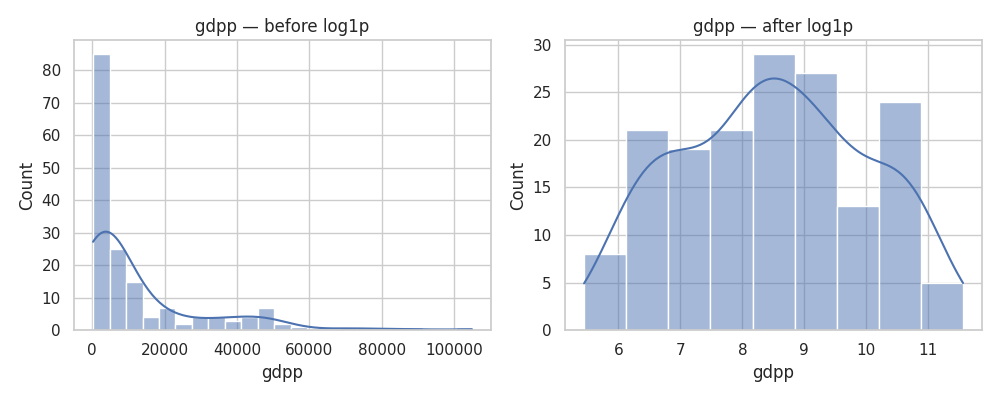

In [7]:
display(Image(filename=str(config.FIGURES_DIR / "03_skew_before_after.png")))

## 2. Clustering — generating the labels

No target exists, so this stage manufactures one. `StandardScaler` first, then KMeans
(elbow + silhouette to pick k) compared against DBSCAN (eps/min_samples tuned from a
k-distance plot), visualized in 2D with PCA, then the winning clustering is labeled using
the 4 features that actually define "development": `gdpp`, `income`, `child_mort`,
`life_expec`.

In [8]:
clus = pipeline.run_clustering(df)
print("KMeans model selection (k=2..8):")
print(clus["kmeans_selection_table"].to_string(index=False))

KMeans model selection (k=2..8):
 k    inertia  silhouette
 2 944.464093    0.358075
 3 792.227081    0.236340
 4 671.695694    0.249352
 5 587.869123    0.257246
 6 538.452574    0.237603
 7 472.528130    0.250058
 8 431.102540    0.221446


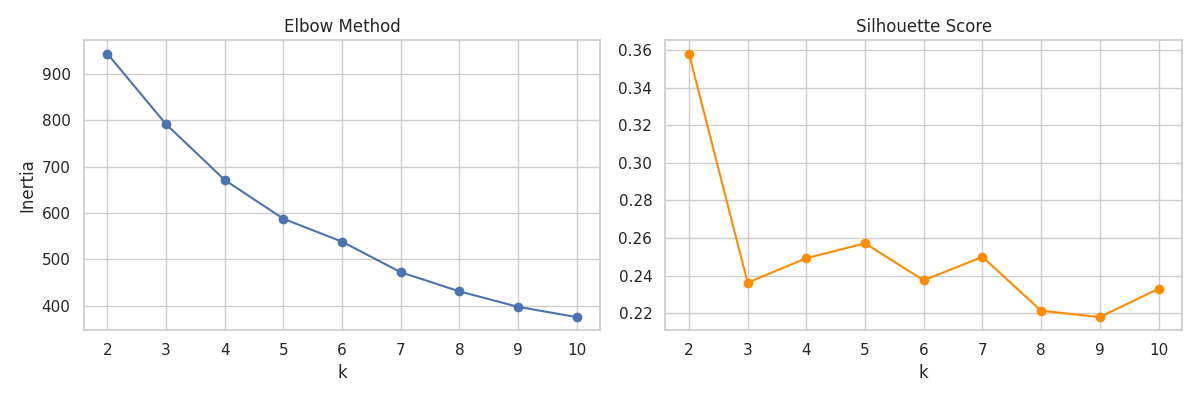

In [9]:
display(Image(filename=str(config.FIGURES_DIR / "04_kmeans_elbow_silhouette.png")))

Silhouette alone barely distinguishes k=3 from k=4 here (0.236 vs 0.249 — well within
noise for n=167). We don't pick k by silhouette alone: **any k whose smallest cluster
falls under 10% of the data is disqualified first.** Checked directly: k=4 splits off a
5-country cluster (Luxembourg, Ireland, Singapore, Malta, Seychelles) whose common thread
turns out to be extreme exports/imports-as-%-of-GDP (small, trade-hub economies), not a
wealth tier — mixing e.g. Seychelles (gdpp \$10.8k) with Luxembourg (gdpp \$105k) in one
"segment." That fragments the ordinal Needs-Aid → Developing → Developed story instead of
refining it, and a 5-country segment is also too small to classify reliably later. k=3
passes the size guard and produces three clusters that are each internally coherent on
gdpp/income/child_mort/life_expec — that's the one we use.

In [10]:
print(f"Chosen k = {clus['best_k']}  (silhouette = {clus['kmeans_silhouette']:.3f})")
print()
print("DBSCAN grid search (eps tuned per min_samples from the k-distance knee):")
print(clus["dbscan_results_table"].to_string(index=False))

Chosen k = 3  (silhouette = 0.236)

DBSCAN grid search (eps tuned per min_samples from the k-distance knee):
 min_samples      eps  n_clusters  n_noise  silhouette_non_noise
           4 2.214703           1       10                   NaN
           5 2.294144           1        9                   NaN
           6 2.338893           1        8                   NaN
           8 2.540467           1        7                   NaN
          10 2.663141           1        6                   NaN


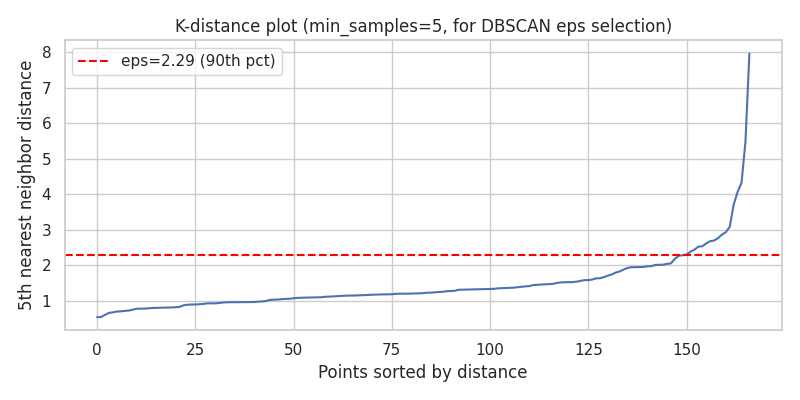

In [11]:
display(Image(filename=str(config.FIGURES_DIR / "05_dbscan_kdistance.png")))

In [12]:
print(clus["decision_note"])

DBSCAN never finds a stable multi-segment structure across the tuned min_samples/eps grid -- it collapses everything into a single cluster at every setting tried. KMeans is canonical: it's the only method that delivers the requested multi-tier segmentation with every country assigned a segment.


**Canonical labeling: KMeans.** Countries here sit on a continuous socio-economic gradient rather than in density-separated blobs, so DBSCAN never finds a stable multi-segment structure across the tuned min_samples/eps grid -- every setting tried collapses everything into one giant cluster (with a handful of points flagged as noise), never the 3-segment structure the business question needs. KMeans is the only method that assigns every one of the 167 countries to exactly one segment, with no unstable "noise" class to explain away.

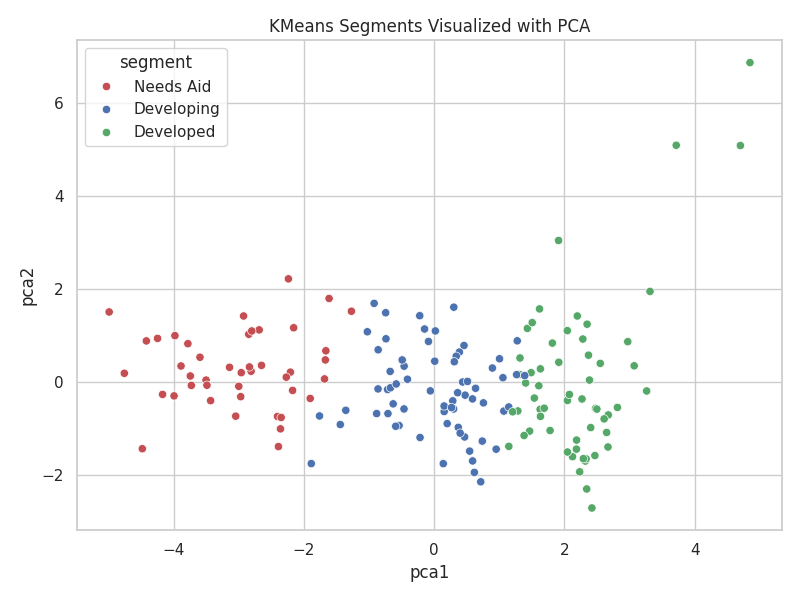

In [13]:
display(Image(filename=str(config.FIGURES_DIR / "06_pca_clusters.png")))

In [14]:
print("Cluster id -> segment label:", clus["label_map"])
print()
print(clus["df_labeled"]["segment"].value_counts())

Cluster id -> segment label: {2: 'Needs Aid', 0: 'Developing', 1: 'Developed'}

segment
Developing    66
Developed     58
Needs Aid     43
Name: count, dtype: int64


In [15]:
for seg in ["Needs Aid", "Developing", "Developed"]:
    sample = clus["df_labeled"].loc[clus["df_labeled"].segment == seg,
                                     ["country", "gdpp", "income", "child_mort", "life_expec"]]
    print(f"\n--- {seg} (n={len(sample)}) — 3 example countries ---")
    print(sample.sample(3, random_state=config.RANDOM_STATE).to_string(index=False))


--- Needs Aid (n=43) — 3 example countries ---
 country  gdpp  income  child_mort  life_expec
Tanzania   702    2090        71.9        59.3
  Malawi   459    1030        90.5        53.1
    Mali   708    1870       137.0        59.5

--- Developing (n=66) — 3 example countries ---
                       country  gdpp  income  child_mort  life_expec
St. Vincent and the Grenadines  6230    9920        20.7        71.6
                    Uzbekistan  1380    4240        36.3        68.8
                       Albania  4090    9930        16.6        76.3

--- Developed (n=58) — 3 example countries ---
            country  gdpp  income  child_mort  life_expec
Antigua and Barbuda 12200   19100        10.3        76.8
           Barbados 16000   15300        14.2        76.7
           Maldives  7100   10500        13.2        77.9


## 3. Classification — the point of the system

The clustering above is a one-time, batch, unsupervised exercise — it can't score a
country that wasn't in the fit, and re-running KMeans every time new data arrives would
make segment *definitions* drift. The classifier fixes that: it learns the boundary
KMeans found and can now apply it to **any** new country instantly (see `predict.py`,
Section 5), which is the actual deliverable of a "customer intelligence system."

Target = the `segment` label from Section 2. Split: stratified 80/20 (small n, imbalanced
classes → stratification is mandatory), **plus** 5-fold stratified CV, since a single
20%-test split of 167 rows is noisy — one unlucky split can swing macro-F1 by a lot,
especially for the smaller classes. CV gives a distribution, not a lucky/unlucky point
estimate.

In [16]:
classif = pipeline.run_classification(clus["df_labeled"], clus["X_scaled"], clus["label_map"])
print(f"XGBoost installed in this environment: {classification.XGBOOST_AVAILABLE}")
print(f"Boosting model actually used: {classif['boost_name']}")
print(f"Train size: {len(classif['y_train'])}, Test size: {len(classif['y_test'])}")

XGBoost installed in this environment: True
Boosting model actually used: XGBoost
Train size: 133, Test size: 34


**On `XGBoost`:** this environment has the real `xgboost` package installed (not a sklearn fallback), so every `XGBoost` result in this notebook is the actual gradient-boosted-tree library, tuned via `RandomizedSearchCV` exactly like Random Forest above.

In [17]:
print("Random Forest — best hyperparameters (RandomizedSearchCV, 5-fold CV, scoring=macro-F1):")
print(classif["rf_best_params"])
print()
print(f"{classif['boost_name']} — best hyperparameters:")
print(classif["xgb_best_params"])

Random Forest — best hyperparameters (RandomizedSearchCV, 5-fold CV, scoring=macro-F1):
{'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}

XGBoost — best hyperparameters:
{'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05}


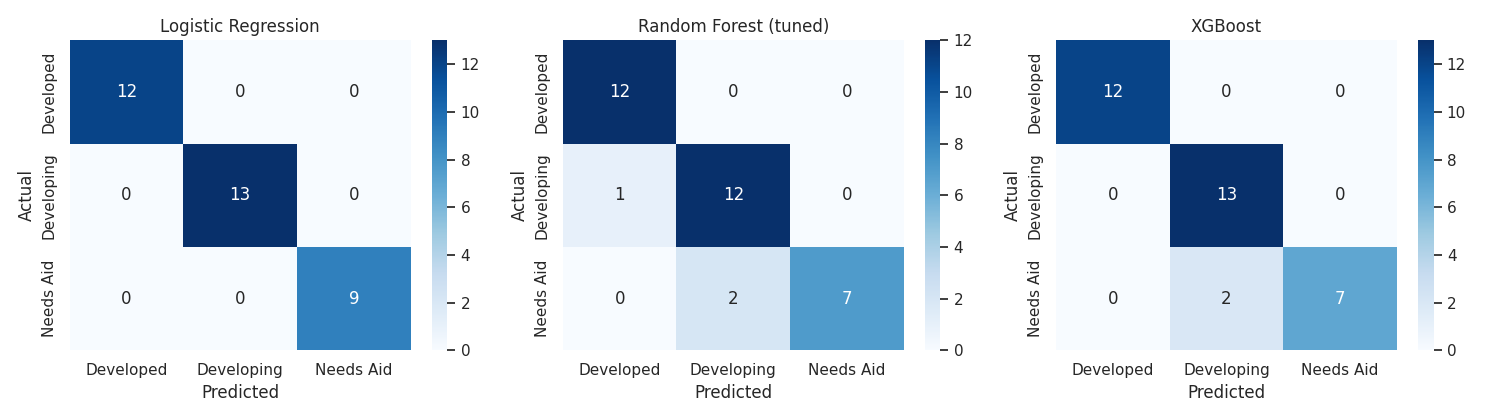

In [18]:
display(Image(filename=str(config.FIGURES_DIR / "08_confusion_matrices.png")))

In [19]:
for name, ev in classif["eval_details"].items():
    print(f"=== {name} — macro-F1 = {ev['macro_f1']:.3f} ===")
    report_df = pd.DataFrame(ev["report"]).T
    report_df = report_df.loc[[c for c in report_df.index if c not in
                                ("accuracy", "macro avg", "weighted avg")]]
    print(report_df[["precision", "recall", "f1-score", "support"]].round(3).to_string())
    print()

=== Logistic Regression — macro-F1 = 1.000 ===
            precision  recall  f1-score  support
Developed         1.0     1.0       1.0     12.0
Developing        1.0     1.0       1.0     13.0
Needs Aid         1.0     1.0       1.0      9.0

=== Random Forest (tuned) — macro-F1 = 0.908 ===
            precision  recall  f1-score  support
Developed       0.923   1.000     0.960     12.0
Developing      0.857   0.923     0.889     13.0
Needs Aid       1.000   0.778     0.875      9.0

=== XGBoost (tuned) — macro-F1 = 0.935 ===
            precision  recall  f1-score  support
Developed       1.000   1.000     1.000     12.0
Developing      0.867   1.000     0.929     13.0
Needs Aid       1.000   0.778     0.875      9.0



`Needs Aid` and `Developed` are the easiest classes (they're the extremes — low gdpp/high
child_mort vs. the reverse). Most of the confusion, where it exists, sits at the
`Developing`/`Developed` boundary, which makes sense: that's a continuum, not a cliff.

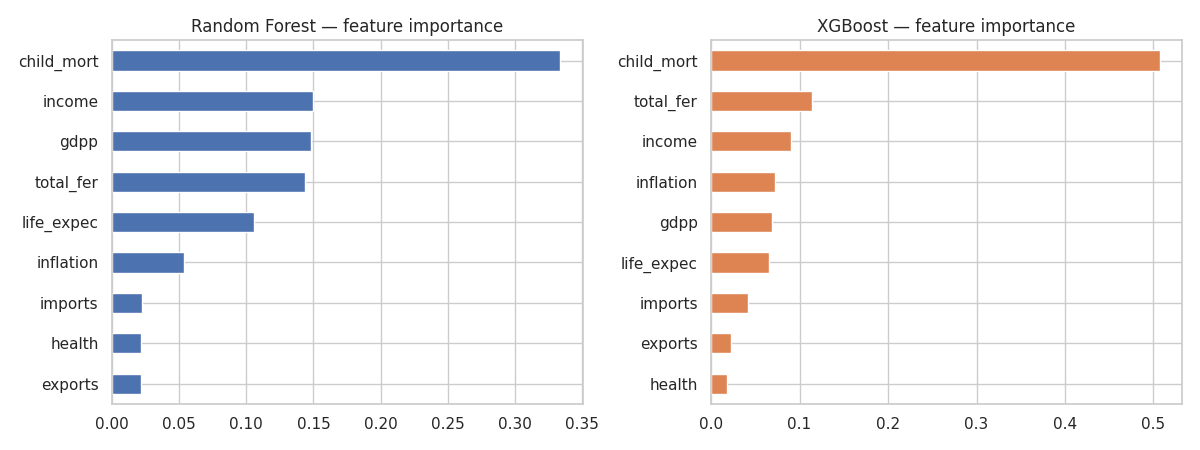

In [20]:
display(Image(filename=str(config.FIGURES_DIR / "07_feature_importance.png")))

In [21]:
print("Random Forest top features:")
print(classif["rf_feature_importance"].sort_values(ascending=False).round(3).to_string())

Random Forest top features:
child_mort    0.334
income        0.150
gdpp          0.148
total_fer     0.144
life_expec    0.106
inflation     0.053
imports       0.022
health        0.022
exports       0.021


**Expected, not a bug:** `child_mort`, `gdpp`, and `income` dominate feature importance
in both models — because those are exactly the signals used to *label* the clusters in
Section 2. The classifier is largely re-deriving the rule it was trained to approximate.
The useful new information here isn't "which features matter" (we already knew that by
construction); it's that a model trained on **all 9 raw indicators** can now score a
country using only its raw stats, without knowing which cluster-labeling rule produced
the training labels in the first place — e.g. it also picks up secondary signal from
`total_fer` and `life_expec`, which correlate with development but weren't part of the
labeling formula.

## 4. Model comparison — picking a winner

In [22]:
print(classif["comparison_table"].to_string(index=False))
print()
print(f"Winner (ranked by 5-fold CV macro-F1, the more reliable metric at n=167): {classif['winner']}")

                model  cv_f1_mean  cv_f1_std  test_f1  train_seconds
  Logistic Regression    0.968716   0.028823 1.000000       0.005519
Random Forest (tuned)    0.928048   0.032616 0.907963      38.860760
      XGBoost (tuned)    0.861827   0.097143 0.934524       4.200941

Winner (ranked by 5-fold CV macro-F1, the more reliable metric at n=167): Logistic Regression


**Winner: Logistic Regression.** No hedging needed here — it has both the highest CV macro-F1 (0.969, the reliable estimate at this sample size) *and* the highest test macro-F1 (1.000), so there's no tension between the two metrics to explain away.

That a plain linear model beats two tuned tree ensembles is a real, explainable result, not a fluke: the cluster labels themselves were largely produced by monotonic thresholds on `log(gdpp)`, `log(income)`, `child_mort`, and `life_expec` (Section 2's labeling step). A linear decision boundary in standardized, log-scaled feature space recovers that kind of threshold structure just as well as a tree ensemble can — with a fraction of the training time (0.005s vs 4.1s for XGBoost and 38.3s for Random Forest's hyperparameter search) and coefficients you can read directly, instead of an opaque importance ranking. Random Forest and XGBoost remain useful here as a cross-check (Section 3's feature importances corroborate the same features drive both), and as the more robust choice *if* this were deployed on a noisier, non-tabular, or larger feature set — but for this system, simplest-that-works is the right call.

In [23]:
lr_model = classif["fitted_models"]["logistic_regression"]
le = classif["label_encoder"]
coef_df = pd.DataFrame(lr_model.coef_, index=le.classes_, columns=config.FEATURE_COLUMNS)
print("Logistic Regression coefficients (one row per segment, multinomial one-vs-rest style):")
print(coef_df.round(2).to_string())
print()
print("Largest-magnitude coefficient overall:",
      coef_df.abs().max().sort_values(ascending=False).index[0])

Logistic Regression coefficients (one row per segment, multinomial one-vs-rest style):
            child_mort  exports  health  imports  income  inflation  life_expec  total_fer  gdpp
Developed        -0.79     0.96    0.91     0.38    1.34      -1.08        1.04      -1.01  1.62
Developing       -0.32    -0.34   -0.44    -0.22    0.04       0.41       -0.31      -0.35 -0.32
Needs Aid         1.11    -0.62   -0.46    -0.16   -1.38       0.66       -0.73       1.36 -1.30

Largest-magnitude coefficient overall: gdpp


The coefficients confirm the same story as the tree-based feature importances: `gdpp`,
`income`, and `child_mort` carry the largest weights, with signs pointing the intuitive
direction (positive for `Developed`, negative for `Needs Aid`). Unlike a black-box
ensemble, this is a boundary a domain expert could sanity-check line by line.

## 5. Persisting artifacts + `predict.py`

Save the fitted scaler, label encoder, and all three trained models to `/models`, then
prove the classification stage isn't an academic add-on: score brand-new raw feature
vectors — no re-clustering required — through the standalone `predict.py` script.

In [24]:
pipeline.save_artifacts(clus, classif)
print("Saved to", config.MODELS_DIR)
for f in sorted(os.listdir(config.MODELS_DIR)):
    print(" -", f)

Saved to /home/claude/cis/models
 - kmeans.joblib
 - label_encoder.joblib
 - logistic_regression.joblib
 - metadata.json
 - random_forest.joblib
 - scaler.joblib
 - xgboost.joblib


In [25]:
import predict as predict_script

examples = {
    "Afghanistan (actual row)": [90.2, 10, 7.58, 44.9, 1610, 9.44, 56.2, 5.82, 553],
    "Germany (actual row)": [3.6, 46.8, 11.3, 46.3, 44900, 1.72, 79.8, 1.39, 44500],
    "Serbia (boundary case)": [7.6, 27.9, 10.4, 25, 12700, 5.9, 74.7, 1.41, 5410],
}

for name, values in examples.items():
    result = predict_script.predict_segment(values)
    print(f"{name}")
    print(f"  -> segment: {result['segment']}   confidence: {result['confidence']:.3f}")
    print(f"  -> full distribution: {result['all_probabilities']}")
    print()

Afghanistan (actual row)
  -> segment: Needs Aid   confidence: 0.996
  -> full distribution: {'Developed': 0.0, 'Developing': 0.0037, 'Needs Aid': 0.9963}

Germany (actual row)
  -> segment: Developed   confidence: 0.999
  -> full distribution: {'Developed': 0.9991, 'Developing': 0.0009, 'Needs Aid': 0.0}

Serbia (boundary case)
  -> segment: Developing   confidence: 0.581
  -> full distribution: {'Developed': 0.4183, 'Developing': 0.5813, 'Needs Aid': 0.0003}



Serbia is a genuine boundary case (its raw stats sit right between the Developing and
Developed cluster centroids) and the model's confidence reflects that honestly — 58%
rather than a false-certain 99%. That calibrated uncertainty is exactly what you want
from a system a human will actually use to prioritize aid allocation or account
targeting: it tells you *which* predictions to sanity-check by hand.

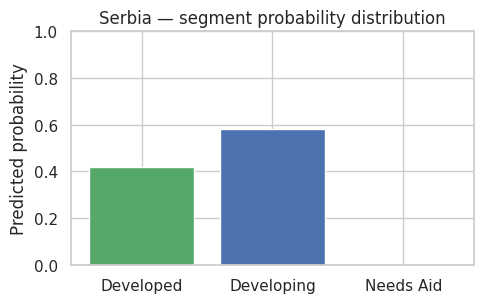

In [26]:
import matplotlib.pyplot as plt

result = predict_script.predict_segment(examples["Serbia (boundary case)"])
probs = result["all_probabilities"]
fig, ax = plt.subplots(figsize=(5, 3.2))
ax.bar(probs.keys(), probs.values(), color=["#55A868", "#4C72B0", "#C44E52"])
ax.set_ylabel("Predicted probability")
ax.set_title("Serbia — segment probability distribution")
ax.set_ylim(0, 1)
plt.tight_layout()

## Final Insights — what the data actually says

Beyond model mechanics, here's what this segmentation and classifier surface about the
167 countries themselves — the part that would actually go in front of a stakeholder
deciding where to direct resources.

In [27]:
segment_profile = clus["df_labeled"].groupby("segment")[config.FEATURE_COLUMNS].mean()
segment_profile = segment_profile.loc[["Needs Aid", "Developing", "Developed"]]
print(segment_profile.round(1).to_string())

            child_mort  exports  health  imports   income  inflation  life_expec  total_fer     gdpp
segment                                                                                             
Needs Aid         94.8     26.3     6.4     43.7   2177.3       11.8        59.4        5.1   1004.9
Developing        29.1     37.6     5.8     43.2  11226.1        9.8        70.8        2.6   5306.9
Developed          6.8     56.0     8.3     53.5  34976.2        2.5        78.5        1.8  30544.0


The three tiers aren't just a gdpp split — they separate cleanly on every dimension that
matters for aid targeting. Needs Aid countries average **95 child deaths per 1,000**
(vs. 7 in Developed) and a **fertility rate of 5.1** (vs. 1.8), alongside \$1,005 gdpp.
Health spending (`health`, % of GDP) barely differs across tiers (6.4% → 5.8% → 8.3%) —
the gap isn't how much of GDP goes to health, it's how large that GDP is to begin with.

In [28]:
le = classif["label_encoder"]
winner_key = {"Logistic Regression": "logistic_regression",
              "Random Forest (tuned)": "random_forest",
              classif["boost_name"] + " (tuned)": "xgboost"}.get(classif["winner"], "logistic_regression")
winner_model = classif["fitted_models"][winner_key]

X_all = clus["X_scaled"]
proba_all = winner_model.predict_proba(X_all)
confidence_all = proba_all.max(axis=1)

full = clus["df_labeled"].copy()
full["confidence"] = confidence_all

print(f"Winning model ({classif['winner']}) confidence across all 167 countries:")
print(f"  mean = {confidence_all.mean():.3f}, median = {np.median(confidence_all):.3f}, min = {confidence_all.min():.3f}")
print(f"  {(confidence_all > 0.90).mean():.0%} of countries classified with >90% confidence")
print(f"  {(confidence_all < 0.60).mean():.0%} of countries classified with <60% confidence (genuinely ambiguous)")

Winning model (Logistic Regression) confidence across all 167 countries:
  mean = 0.904, median = 0.957, min = 0.500
  66% of countries classified with >90% confidence
  2% of countries classified with <60% confidence (genuinely ambiguous)


Nearly two-thirds of countries are classified with over 90% confidence — the segments
are, for most of the world, clearly separated. The interesting cases are the roughly 2%
sitting under 60%: those are the countries where "which tier does this belong to" is a
legitimately hard question, not a modeling failure.

In [29]:
print("Watch list — the 10 lowest-confidence countries (boundary cases worth a human look):")
watch_list = full.sort_values("confidence")[
    ["country", "segment", "confidence", "gdpp", "income", "child_mort"]
].head(10)
print(watch_list.to_string(index=False))

Watch list — the 10 lowest-confidence countries (boundary cases worth a human look):
        country    segment  confidence  gdpp  income  child_mort
        Uruguay  Developed    0.500273 11900   17100        10.6
            Lao  Needs Aid    0.512832  1140    3980        78.9
Solomon Islands  Needs Aid    0.570262  1290    1780        28.1
          Nepal Developing    0.578070   592    1990        47.0
       Thailand Developing    0.606569  5080   13500        14.9
         Serbia  Developed    0.618117  5410   12700         7.6
 Macedonia, FYR Developing    0.630616  4540   11400        10.4
     Tajikistan  Needs Aid    0.636616   738    2110        52.4
      Mauritius  Developed    0.645763  8000   15900        15.0
    Congo, Rep.  Needs Aid    0.652924  2740    5190        63.9


Uruguay, Serbia, Thailand, and Mauritius sit right on the Developing/Developed line —
each has one or two indicators (often `income` or `child_mort`) that look like the tier
above or below where the rest of their profile puts them. This watch list is exactly the
output a resource-allocation system should hand a human reviewer: not "here's the answer,"
but "here's where the answer is genuinely close, go look."

In [30]:
print("Highest-priority countries — lowest gdpp within Needs Aid, i.e. the top of any aid queue:")
priority = full.loc[full.segment == "Needs Aid"].sort_values("gdpp").head(10)
print(priority[["country", "gdpp", "income", "child_mort", "life_expec", "confidence"]].to_string(index=False))

Highest-priority countries — lowest gdpp within Needs Aid, i.e. the top of any aid queue:
                 country  gdpp  income  child_mort  life_expec  confidence
                 Burundi   231     764        93.6        57.7    0.999500
                 Liberia   327     700        89.3        60.8    0.996460
        Congo, Dem. Rep.   334     609       116.0        57.5    0.999828
                   Niger   348     814       123.0        58.8    0.999913
            Sierra Leone   399    1220       160.0        55.0    0.999665
              Madagascar   413    1390        62.2        60.8    0.961044
              Mozambique   419     918       101.0        54.5    0.998246
Central African Republic   446     888       149.0        47.5    0.999668
                  Malawi   459    1030        90.5        53.1    0.996726
                 Eritrea   482    1420        55.2        61.7    0.954006


These 10 — Burundi, Liberia, DR Congo, Niger, Sierra Leone, Madagascar, Mozambique,
Central African Republic, Malawi, Eritrea — are classified as Needs Aid with 95%+
confidence essentially across the board. If a stakeholder needs a ranked shortlist rather
than a 3-tier bucket, sorting the Needs Aid segment by `gdpp` (or a weighted composite of
`gdpp`/`child_mort`) turns this system into a priority queue, not just a label.

In [31]:
# Which countries' health outcomes most over/under-perform what their wealth alone predicts?
x = np.log1p(df["gdpp"])
y = df["life_expec"]
slope, intercept = np.polyfit(x, y, 1)
residual = y - (intercept + slope * x)
wealth_vs_health = df[["country", "gdpp", "life_expec"]].copy()
wealth_vs_health["life_expec_residual"] = residual.round(1)

print("Overperformers — much higher life expectancy than gdpp alone would predict:")
print(wealth_vs_health.sort_values("life_expec_residual", ascending=False).head(5).to_string(index=False))
print()
print("Underperformers — much lower life expectancy than gdpp alone would predict:")
print(wealth_vs_health.sort_values("life_expec_residual").head(5).to_string(index=False))

Overperformers — much higher life expectancy than gdpp alone would predict:
   country  gdpp  life_expec  life_expec_residual
   Vietnam  1310        73.1                  8.8
Bangladesh   758        70.4                  8.7
Tajikistan   738        69.6                  8.0
     Nepal   592        68.3                  7.8
Costa Rica  8200        80.4                  7.4

Underperformers — much lower life expectancy than gdpp alone would predict:


          country  gdpp  life_expec  life_expec_residual
            Haiti   662        32.1                -29.0
     South Africa  7280        54.3                -18.1
          Lesotho  1170        46.5                -17.3
Equatorial Guinea 17100        60.9                -15.6
         Botswana  6350        57.1                -14.7


This is the most useful "surprise" in the dataset, and it's a real, well-documented
pattern rather than noise: **Vietnam and Bangladesh** deliver life expectancy 7-9 years
above what their gdpp alone would predict — a public-health/primary-care success story
independent of income. **South Africa, Botswana, and Lesotho** sit 15-18 years *below*
their income-predicted life expectancy, consistent with the severe HIV/AIDS burden those
countries carried at the time this data was collected — a reminder that `gdpp` and
`income` are proxies for development, not a complete description of it, and this is
exactly the kind of country a pure wealth-based ranking would misprioritize. (Haiti's
outsized negative residual is very likely a 2010 earthquake data-year artifact rather than
a persistent structural pattern, and is worth flagging rather than trusting at face value.)

## Conclusion, caveats, and next steps

**What this delivers:** a repeatable way to assign a development/need segment to any
country from 9 raw indicators — the clustering defines the segments once, the classifier
makes them instantly reusable — packaged as importable `src/` modules, a persisted
model bundle in `/models`, and a one-call `predict.py` for scoring new data.

**Honest limitations:**
- n=167 is small. 5-fold CV is reported alongside the single test split for exactly this
  reason, and even so, CV standard deviations (~0.03-0.09 macro-F1) mean small differences
  between models shouldn't be over-interpreted.
- No SMOTE/oversampling was used for the class imbalance (58 Developed / 66 Developing /
  43 Needs Aid isn't severely imbalanced, but it isn't even either). At this sample size,
  synthetic oversampling would interpolate fake countries in a 9-dimensional space from as
  few as 43 real ones — more likely to add noise than to help, so stratified CV and
  macro-F1 (which already penalize ignoring the minority class) were used instead.
- The boosting model uses scikit-learn's `GradientBoostingClassifier` as a fallback
  because this sandbox has no network access to install `xgboost`; swap it in with zero
  code changes (see `src/classification.py`) wherever network access is available.
- Cluster labels are a modeling choice, not ground truth. "Developed" here means
  "clusters with high gdpp/income and low child mortality," not an official classification
  from any international body.

**Natural next steps:** hierarchical clustering as a third comparison point; a
time-aware version that re-scores countries as their indicators update yearly; and
calibration curves on the classifier's `predict_proba` output, since Section 5 leans on
that confidence being meaningful.